In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/sessions_14days.csv')

Mounted at /content/drive


 Гипотеза 4 БУДНИ vs ВЫХОДНЫЕ × ВРЕМЯ СУТОК

Конверсия по будням/выходным × времени:
         day_time  sessions  purchases  conversion
3      Будни Утро    813436      71090        8.74
7   Выходные Утро    616503      49601        8.05
2      Будни Ночь    457259      33343        7.29
6   Выходные Ночь    351961      23505        6.68
1      Будни День    848798      49834        5.87
5   Выходные День    634042      34936        5.51
0     Будни Вечер    242904      12646        5.21
4  Выходные Вечер    191210       9613        5.03


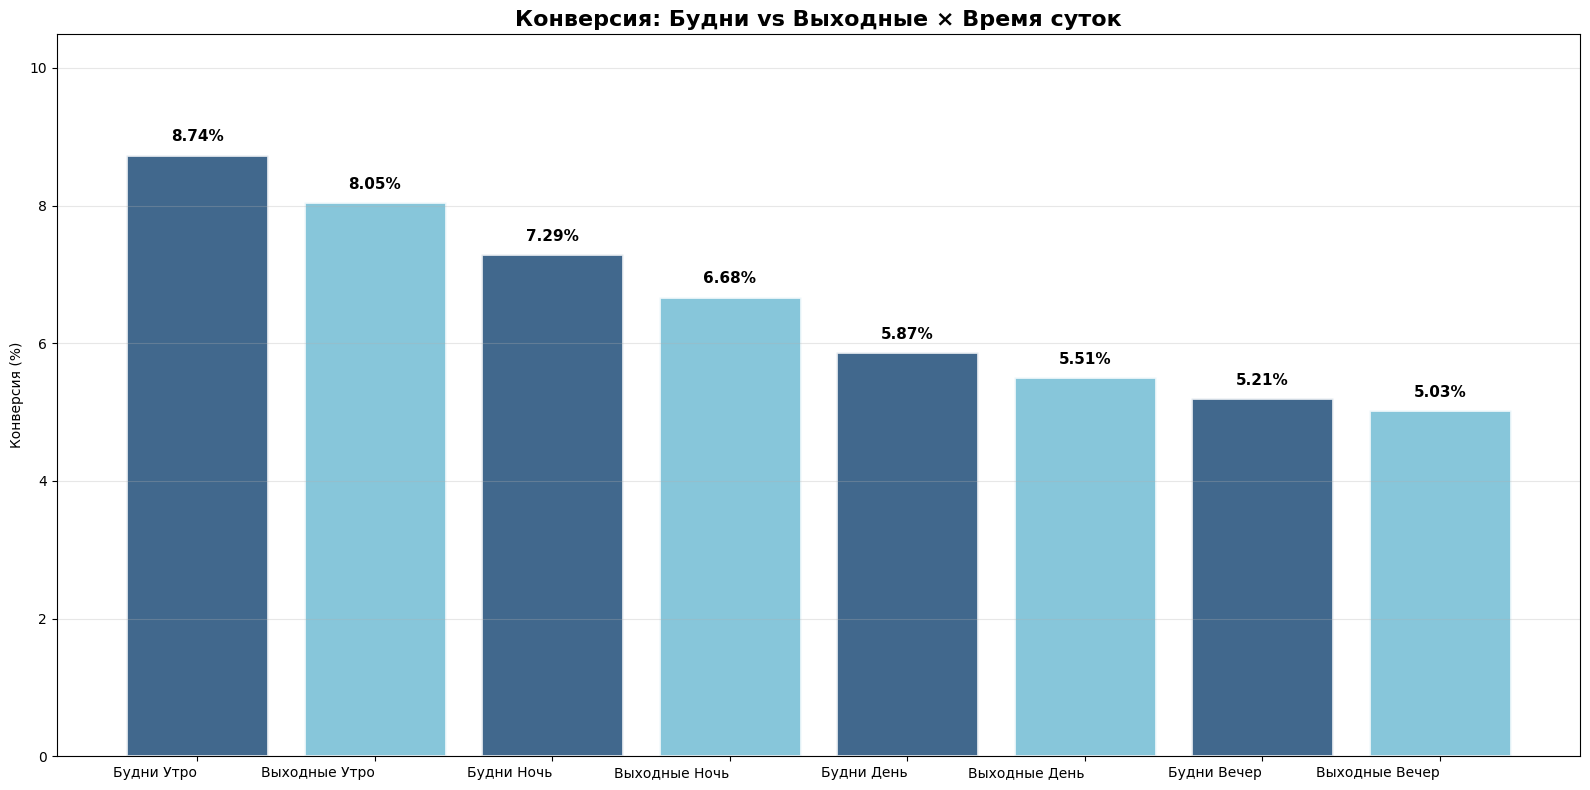


 ТОП-3 по конверсии:
        day_time  conversion  sessions
3     Будни Утро        8.74    813436
7  Выходные Утро        8.05    616503
2     Будни Ночь        7.29    457259

 АНТИТОП-3:
         day_time  conversion  sessions
5   Выходные День        5.51    634042
0     Будни Вечер        5.21    242904
4  Выходные Вечер        5.03    191210


In [14]:
# 8 комбинаций
df['day_type'] = df['is_weekend'].map({0: 'Будни', 1: 'Выходные'})
df['time_cat'] = df['start_hour'].apply(lambda h:
    'Утро' if 6<=h<12 else 'День' if 12<=h<18 else 'Вечер' if 18<=h<24 else 'Ночь')

df['day_time'] = df['day_type'] + ' ' + df['time_cat']

# Конверсия по 8 группам
daytime_conv = df.groupby('day_time').agg(
    sessions=('made_purchase', 'count'),
    purchases=('made_purchase', 'sum'),
    conversion=('made_purchase', 'mean')
).reset_index()

daytime_conv['conversion'] = daytime_conv['conversion'] * 100
daytime_conv = daytime_conv.sort_values('conversion', ascending=False)

print("Конверсия по будням/выходным × времени:")
print(daytime_conv.round(2))

#  График
plt.figure(figsize=(16, 8))
colors = ['#1f4e79', '#72bcd4'] * 4
bars = plt.bar(range(len(daytime_conv)), daytime_conv['conversion'],
               color=colors[:8], alpha=0.85, edgecolor='white', linewidth=2)

# Подписи
max_conv = max(daytime_conv['conversion'])
for i, (bar, v) in enumerate(zip(bars, daytime_conv['conversion'])):
    plt.text(bar.get_x() + bar.get_width()/2., v + 0.15, f'{v:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.xticks(range(len(daytime_conv)), daytime_conv['day_time'], ha='right')
plt.title('Конверсия: Будни vs Выходные × Время суток', fontweight='bold', fontsize=16)
plt.ylabel('Конверсия (%)')
plt.ylim(0, max_conv * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hyp5_daytime_split.png', dpi=300, bbox_inches='tight')
plt.show()


print("\n ТОП-3 по конверсии:")
print(daytime_conv.head(3)[['day_time', 'conversion', 'sessions']].round(2))
print("\n АНТИТОП-3:")
print(daytime_conv.tail(3)[['day_time', 'conversion', 'sessions']].round(2))

In [11]:
key_pairs = [
    ('Будни Утро', 'Будни День'),
    ('Будни Ночь', 'Будни Вечер'),
    ('Выходные Утро', 'Выходные День'),
    ('Выходные Ночь', 'Выходные Вечер')
]

alpha_bonf = 0.05 / 4  # 4 теста поправка Бонферрони
results = []

for pair in key_pairs:
    i, j = [daytime_conv[daytime_conv['day_time'] == p].index[0] for p in pair]
    count = [daytime_conv.iloc[i]['purchases'], daytime_conv.iloc[j]['purchases']]
    nobs = [daytime_conv.iloc[i]['sessions'], daytime_conv.iloc[j]['sessions']]
    stat, pval = proportions_ztest(count, nobs)

    significant = "✅" if pval < alpha_bonf else "❌"
    delta = daytime_conv.iloc[i]['conversion'] - daytime_conv.iloc[j]['conversion']

    results.append({
        'Пара': f"{pair[0]} vs {pair[1]}",
        'Δ%': f"+{delta:.2f}%",
        'Z': f"{stat:.1f}",
        'p': f"{pval:.1e}",
        'Значимо': significant
    })



results_df = pd.DataFrame(results)
print("\nРЕЗУЛЬТАТЫ (Бонферрони α=0.0125):")
print(results_df.to_markdown(index=False))


📊 РЕЗУЛЬТАТЫ (Бонферрони α=0.0125):
| Пара                            | Δ%      |     Z |        p | Значимо   |
|:--------------------------------|:--------|------:|---------:|:----------|
| Будни Утро vs Будни День        | +-1.37% | -24.5 | 1.6e-132 | ✅        |
| Будни Ночь vs Будни Вечер       | +-1.45% | -28.5 | 7.6e-179 | ✅        |
| Выходные Утро vs Выходные День  | +-0.48% |  -8.2 | 2.7e-16  | ✅        |
| Выходные Ночь vs Выходные Вечер | +-0.66% | -12.4 | 1.6e-35  | ✅        |
